# No Show EDA

Exploratory data analysis of first datadump of no-show

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import pandas as pd

from ipywidgets import interact
from noshow.config import CLINIC_CONFIG
from pathlib import Path
from noshow.features.appointment_features import (
    add_appointments_last_days,
    add_appointments_same_day,
    add_days_since_created,
    add_days_since_last_appointment,
    add_minutes_early,
    add_time_features,
)
from noshow.features.no_show_features import prev_no_show_features
from noshow.features.patient_features import add_patient_features
from noshow.preprocessing.load_data import (
    load_appointment_csv,
    process_appointments,
    process_postal_codes,
)
from noshow.features.feature_pipeline import create_features
from noshow.visualisation.features_plots import feature_barplot, feature_scatter
from noshow.preprocessing.geo import haversine_distance

## Read and clean data

In [3]:
appointments_df = load_appointment_csv("../data/raw/poliafspraken_no_show.csv")
appointments_df = process_appointments(appointments_df, CLINIC_CONFIG)

/home/jovyan/No_Show/src/noshow/preprocessing/load_data.py:52: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  appointments_df = pd.read_csv(


test!!@
non unique index:
1371234


In [4]:
'''
june_filter = pd.Timestamp('2021-06-01').timestamp()
appointments_df = appointments_df.reset_index()
appointments_df['start'] = pd.to_datetime(appointments_df['start'], unit='s')
appointments_df = appointments_df[appointments_df['start'] >= '2021-06-01']
appointments_df = appointments_df.set_index(['pseudo_id', 'start'])
'''

"\njune_filter = pd.Timestamp('2021-06-01').timestamp()\nappointments_df = appointments_df.reset_index()\nappointments_df['start'] = pd.to_datetime(appointments_df['start'], unit='s')\nappointments_df = appointments_df[appointments_df['start'] >= '2021-06-01']\nappointments_df = appointments_df.set_index(['pseudo_id', 'start'])\n"

## Plot no-shows

In [5]:
appointments_dt = load_appointment_csv("../data/raw/poliafspraken_no_show.csv")

/home/jovyan/No_Show/src/noshow/preprocessing/load_data.py:52: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  appointments_df = pd.read_csv(


In [6]:
# Count occurrences of each value in 'hoofdagenda'
hoofdagenda_counts = appointments_df['hoofdagenda'].value_counts()

# Filter values that occur less than 1068 times
valid_values = hoofdagenda_counts[hoofdagenda_counts >= 1068].index

# Filter the DataFrame to include only rows with valid 'hoofdagenda' values
appointments_df = appointments_df[appointments_df['hoofdagenda'].isin(valid_values)]

In [7]:
print(valid_values)

Index(['INTERNE GENEESKUNDE', 'GYNAECOLOGIE', 'OOGHEELKUNDE', 'CARDIOLOGIE',
       'CHIRURGIE', 'KNO', 'UROLOGIE', 'LONGGENEESKUNDE', 'NEUROLOGIE',
       'DERMATOLOGIE', 'REUMATOLOGIE', 'MDL', 'KAAKCHIRURGIE',
       'PLASTISCHE CHIRURGIE', 'HEMATOLOGIE', 'GIPSKAMER', 'HARTREVALIDATIE',
       'NEUROCHIRURGIE', 'FYSIOTHERAPIE', 'MEDISCHE PSYCHOLOGIE',
       'RADIOTHERAPIE', 'FUNCTIE CARDIOLOGIE', 'PIJNGENEESKUNDE',
       'CARDIOTHORACALE CHIRURGIE', 'DIETETIEK', 'OUDERENGENEESKUNDE',
       'FUNCTIE LONG', 'ANESTHESIOLOGIE', 'MAATSCHAPPELIJK WERK',
       'FUNCTIE SCOPIE', 'PSYCHIATRIE'],
      dtype='object', name='hoofdagenda')


In [8]:
appointments_df['hoofdagenda'].count()

1368259

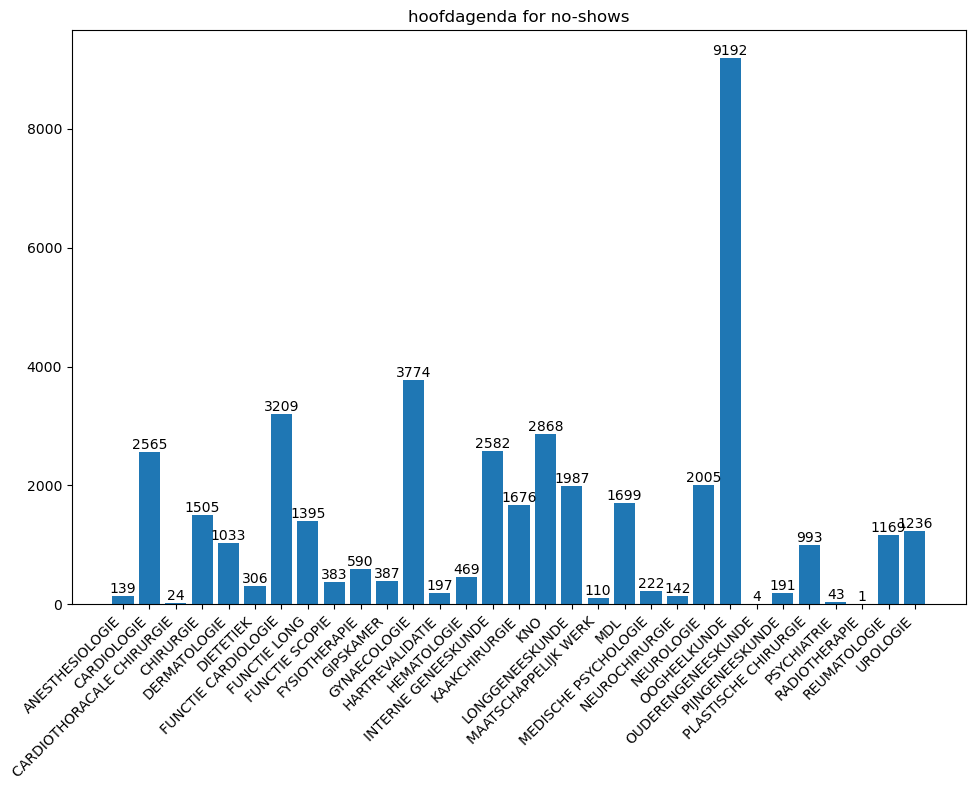

In [9]:
cancelation_reason_count = (
    appointments_df[appointments_df["no_show"] == "no_show"]
    .groupby("hoofdagenda")["no_show"]
    .count()
)

fig, ax = plt.subplots(figsize=(10, 8))

bar_container = ax.bar(cancelation_reason_count.index, cancelation_reason_count)
ax.bar_label(bar_container)
ax.set_xticks(range(len(cancelation_reason_count.index)))
ax.set_xticklabels(cancelation_reason_count.index, rotation=45, ha="right")
ax.set_title("hoofdagenda for no-shows")
fig.set_layout_engine("tight")
plt.show()


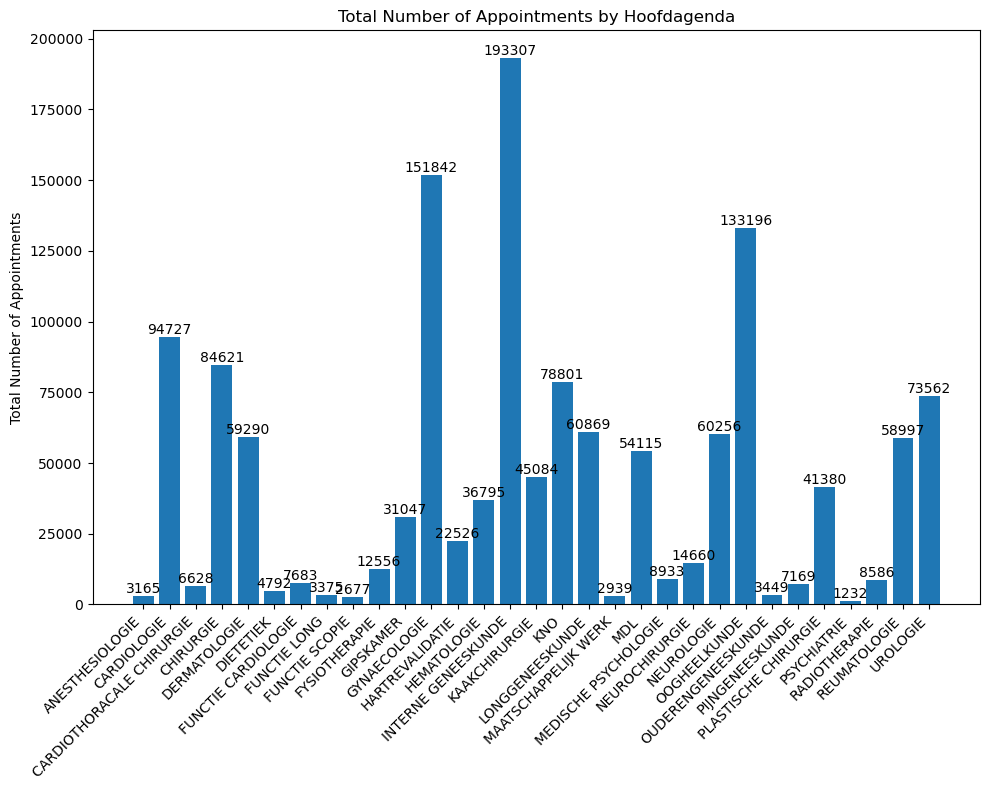

In [63]:
# Calculate the total appointments per hoofdagenda (including no-shows and others)
total_appointments = appointments_df.groupby("hoofdagenda")["no_show"].count()

# Create the plot for total number of appointments
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the bar chart for total appointments
bar_container = ax.bar(total_appointments.index, total_appointments)
ax.bar_label(bar_container)

# Formatting the plot
ax.set_xticks(range(len(total_appointments.index)))
ax.set_xticklabels(total_appointments.index, rotation=45, ha="right")
ax.set_title("Total Number of Appointments by Hoofdagenda")
ax.set_ylabel("Total Number of Appointments")
fig.tight_layout()  # Adjust layout

# Show the plot
plt.show()


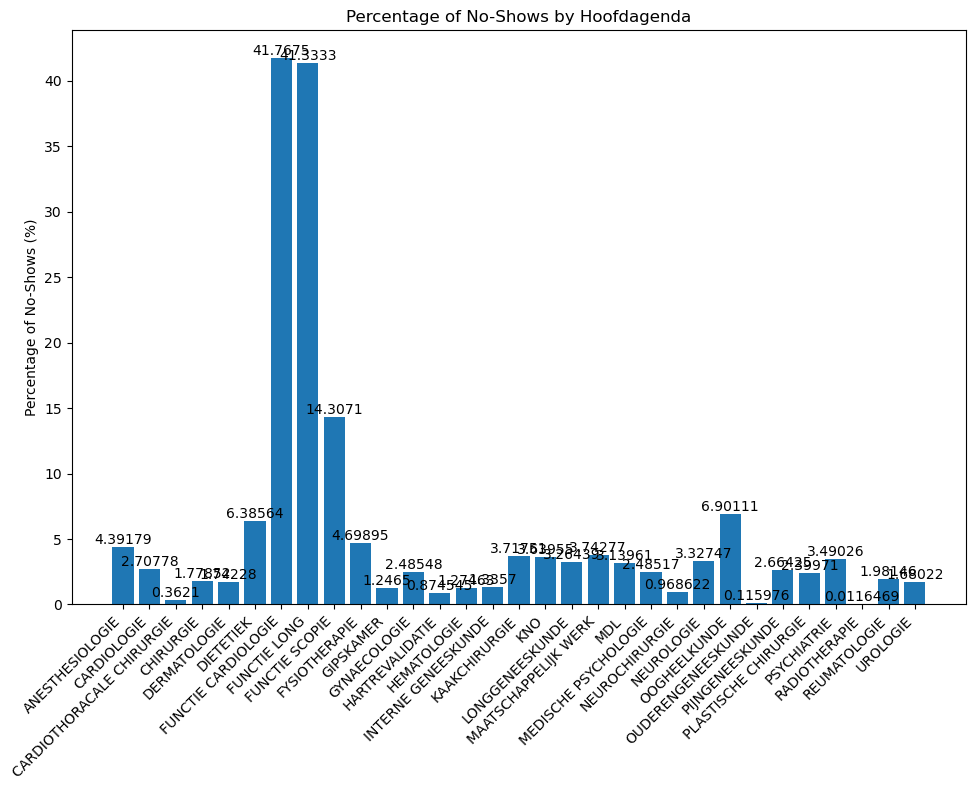

In [62]:
# Calculate the count of no-shows per hoofdagenda
no_show_count = appointments_df[appointments_df["no_show"] == "no_show"].groupby("hoofdagenda")["no_show"].count()

# Calculate the total appointments per hoofdagenda (including no-shows and others)
total_appointments = appointments_df.groupby("hoofdagenda")["no_show"].count()

# Calculate the percentage of no-shows
cancelation_reason_percentage = (no_show_count / total_appointments) * 100

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the bar chart with percentages
bar_container = ax.bar(cancelation_reason_percentage.index, cancelation_reason_percentage)
ax.bar_label(bar_container)

# Formatting the plot
ax.set_xticks(range(len(cancelation_reason_percentage.index)))
ax.set_xticklabels(cancelation_reason_percentage.index, rotation=45, ha="right")
ax.set_title("Percentage of No-Shows by Hoofdagenda")
ax.set_ylabel("Percentage of No-Shows (%)")
fig.tight_layout()  # Adjust layout

# Show the plot
plt.show()


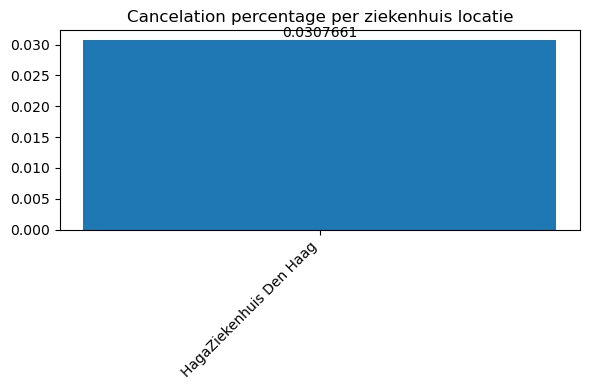

In [10]:
ziekenhuis_count = ( 
    appointments_df[appointments_df["no_show"] == "no_show"]
    .groupby("ziekenhuis")["no_show"]
    .count()
    /
    appointments_df
    .groupby("ziekenhuis")["no_show"]
    .count()
)

fig, ax = plt.subplots(figsize=(6, 4))

bar_container = ax.bar(ziekenhuis_count.index, ziekenhuis_count)
ax.bar_label(bar_container)
ax.set_xticks(range(len(ziekenhuis_count.index)))
ax.set_xticklabels(ziekenhuis_count.index, rotation=45, ha="right")
ax.set_title("Cancelation percentage per ziekenhuis locatie")
fig.set_layout_engine("tight")
plt.tight_layout()
plt.show()

---


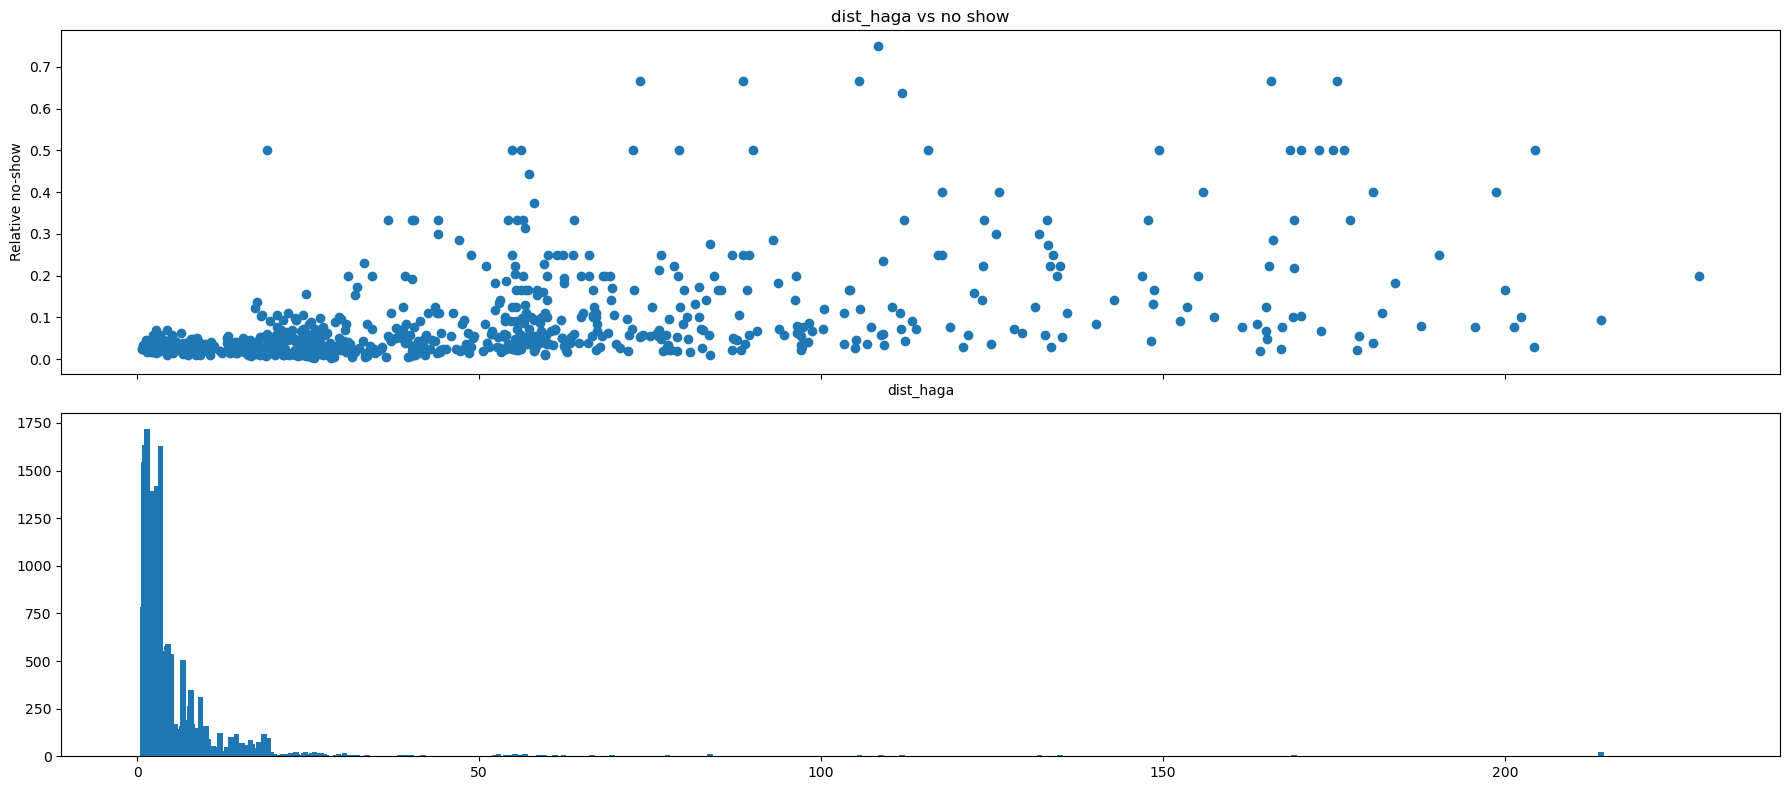

In [11]:
all_postalcodes = process_postal_codes("../data/raw/NL.csv")

cancelation_reason_count = ( 
    appointments_df[appointments_df["no_show"] == "no_show"]
)

appointments_features = create_features(appointments_df, all_postalcodes)

ax = feature_scatter(appointments_features, "dist_umcu",feature_name = "dist_haga", figsize=(18, 8))
plt.tight_layout()
plt.show()

In [12]:
#get median distance for patient, plot agains latest no show percentage per patient


In [2]:
print(appointments_features)

NameError: name 'appointments_features' is not defined

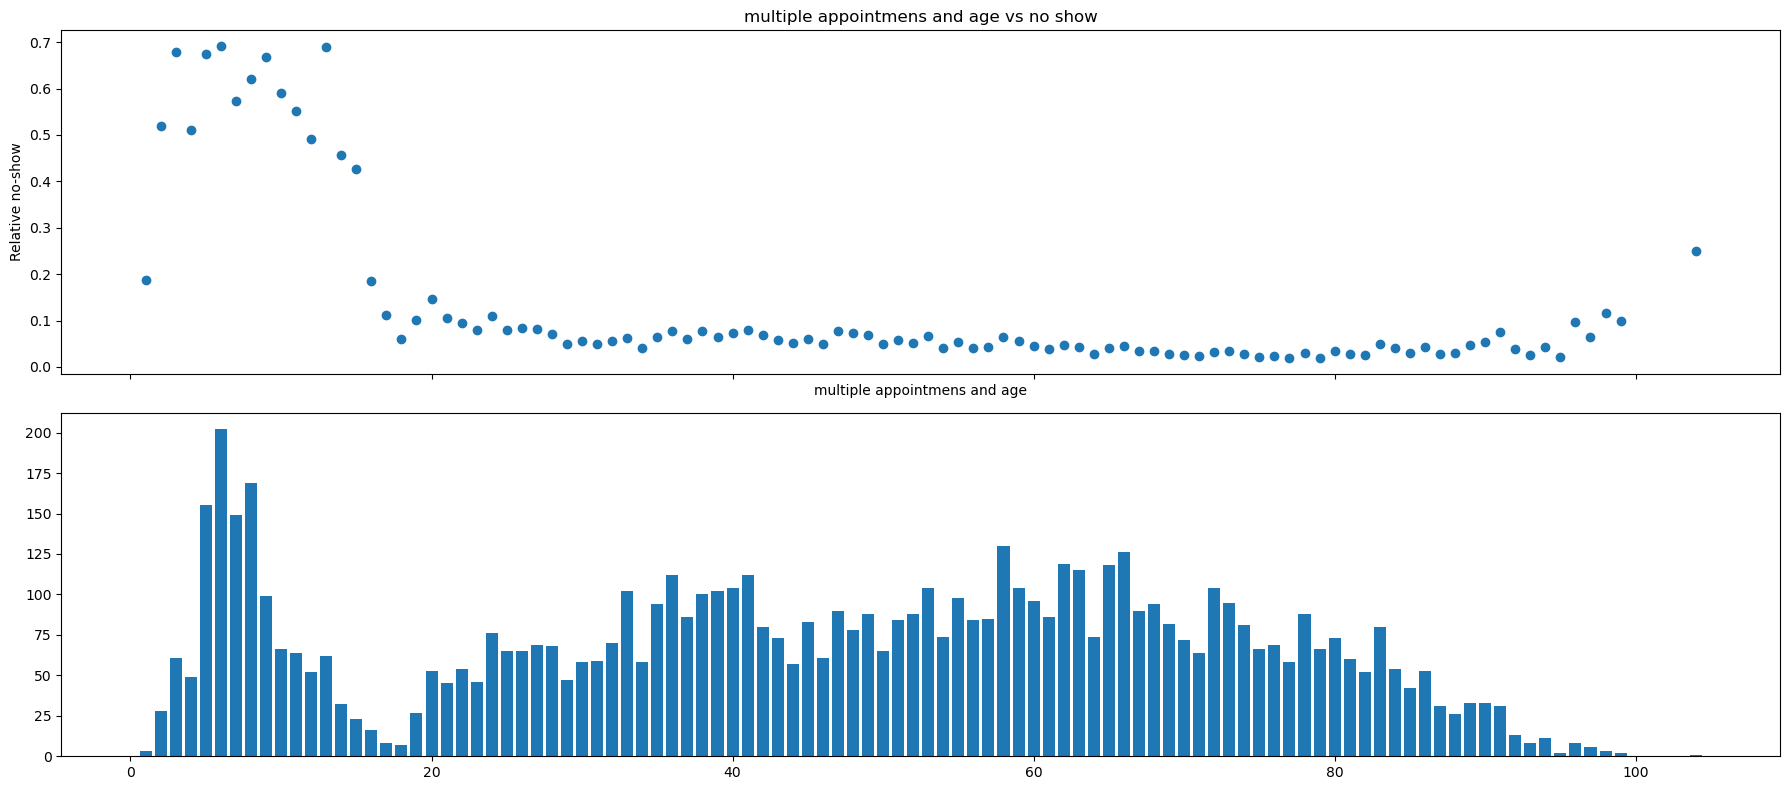

In [13]:
appoints_durr = appointments_features[appointments_features['appointments_same_day'] == 2]
ax = feature_scatter(appoints_durr, "age", figsize=(18, 8), feature_name="multiple appointmens and age")
plt.tight_layout()
plt.show()

In [14]:
test = appointments_features[appointments_features['appointments_same_day'] == 3]

total = len(test)

under_20 = (test['no_show'] == 'no_show').sum()

perc = (under_20 / total) * 100

print(perc)

3.428201811125485


In [15]:
total = len(appointments_features)

under_20 = (appointments_features['age'] <= 20).sum()

perc = (under_20 / total) * 100

print(perc)

2.57376957936766


In [16]:
total = len(appoints_durr)

under_20 = (appoints_durr['age'] <= 20).sum()

perc = (under_20 / total) * 100

print(perc)

2.316147813499197


In [17]:
copy = appoints_durr[appoints_durr['age'] <= 20]

total = len(copy)

under_20 = (copy['no_show'] == 'no_show').sum()

perc = (under_20 / total) * 100

print(total)
print(perc)

2912
45.50137362637363


In [18]:
df_filter = appointments_features[appointments_features['no_show'] == 'no_show'].copy()

total = len(df_filter)

under_20 = (df_filter['age'] <= 20).sum()

perc = (under_20 / total) * 100

print(perc)

9.500574052812858


In [19]:
df_reset = appoints_durr.reset_index()
duplicates = df_reset[df_reset.duplicated(subset=['pseudo_id', 'start'], keep=False)]
print(duplicates.sort_values(['pseudo_id', 'start']))

Empty DataFrame
Columns: [pseudo_id, start, APP_ID, wat_id?, hoofdagenda, hoofdagenda_id, subagenda_id, specialty_code, soort_consult, afspraak_code, end, arrival, created, minutesDuration, status, status_code_original, cancelationReason_code, cancelationReason_display, BIRTH_YEAR, address_postalCodeNumbersNL, name, description, ziekenhuis, soort_cons, ConsultTypeDescription, geen_idee, gender, geen_id, no_show, prev_no_show, earlier_appointments, prev_no_show_perc, appointments_same_day, days_since_last_appointment, days_since_created, appointments_last_days, minutes_early, prev_minutes_early, weekday, hour, latitude, longitude, dist_umcu, age]
Index: []

[0 rows x 44 columns]


In [20]:
#print(appointments_features.count())
df_test = appointments_features.reset_index()
pseudo = df_test['pseudo_id'].value_counts()

single = pseudo[pseudo == 1]
num = single.count()
print(num)

55441


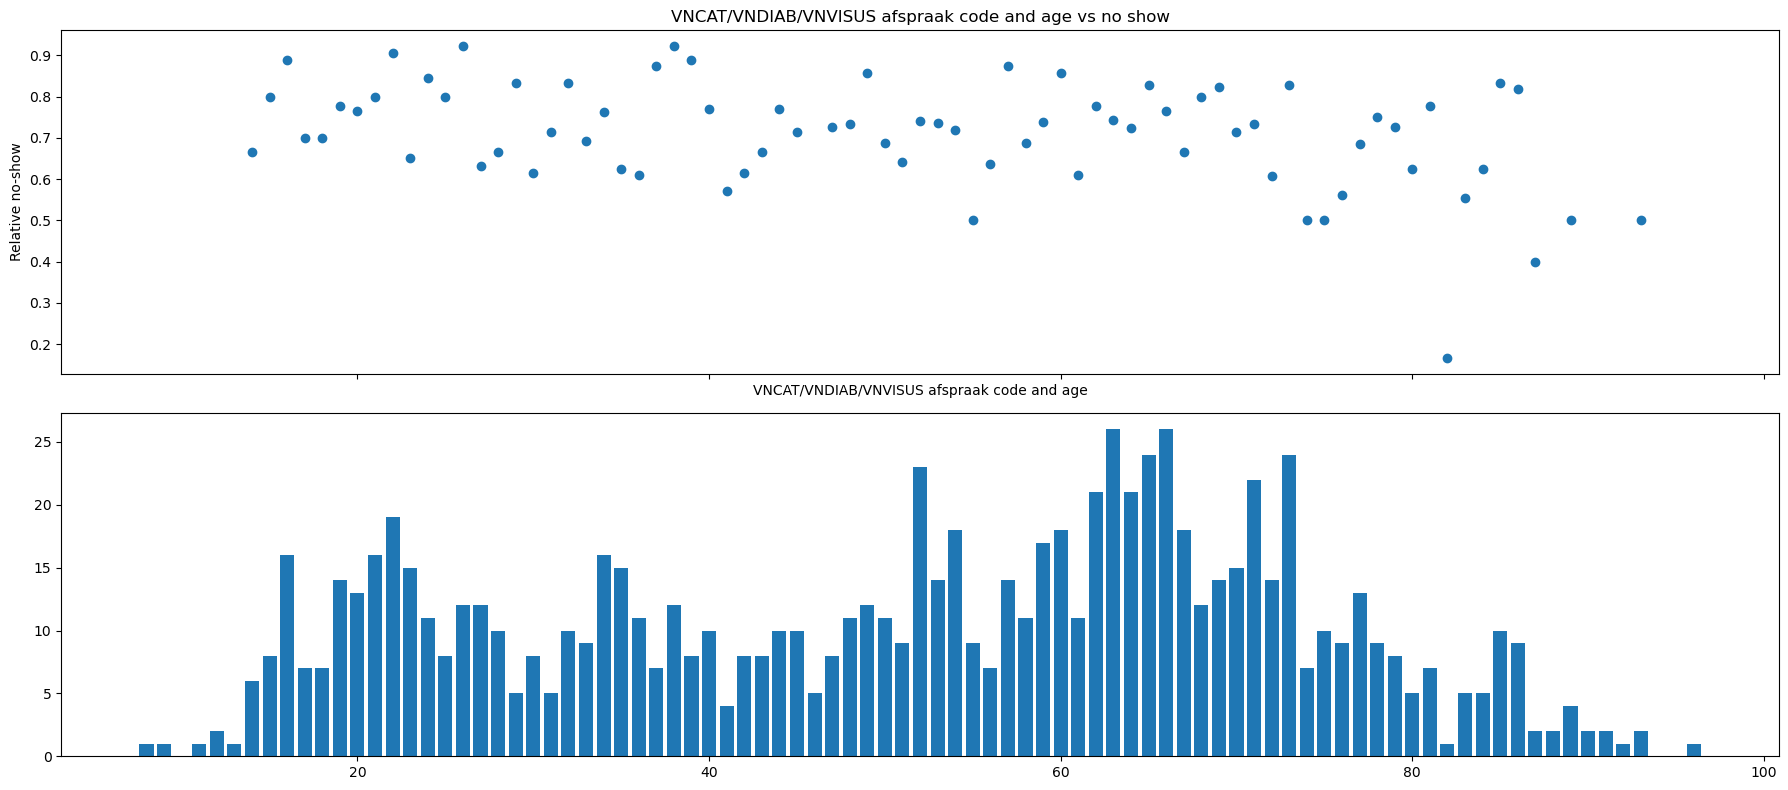

In [21]:
new = appointments_features[appointments_features['afspraak_code'].isin(['VNCAT', 'VNDIAB', 'VNVISUS'])]
ax = feature_scatter(new, "age", figsize=(18, 8), feature_name='VNCAT/VNDIAB/VNVISUS afspraak code and age')
plt.tight_layout()
plt.show()

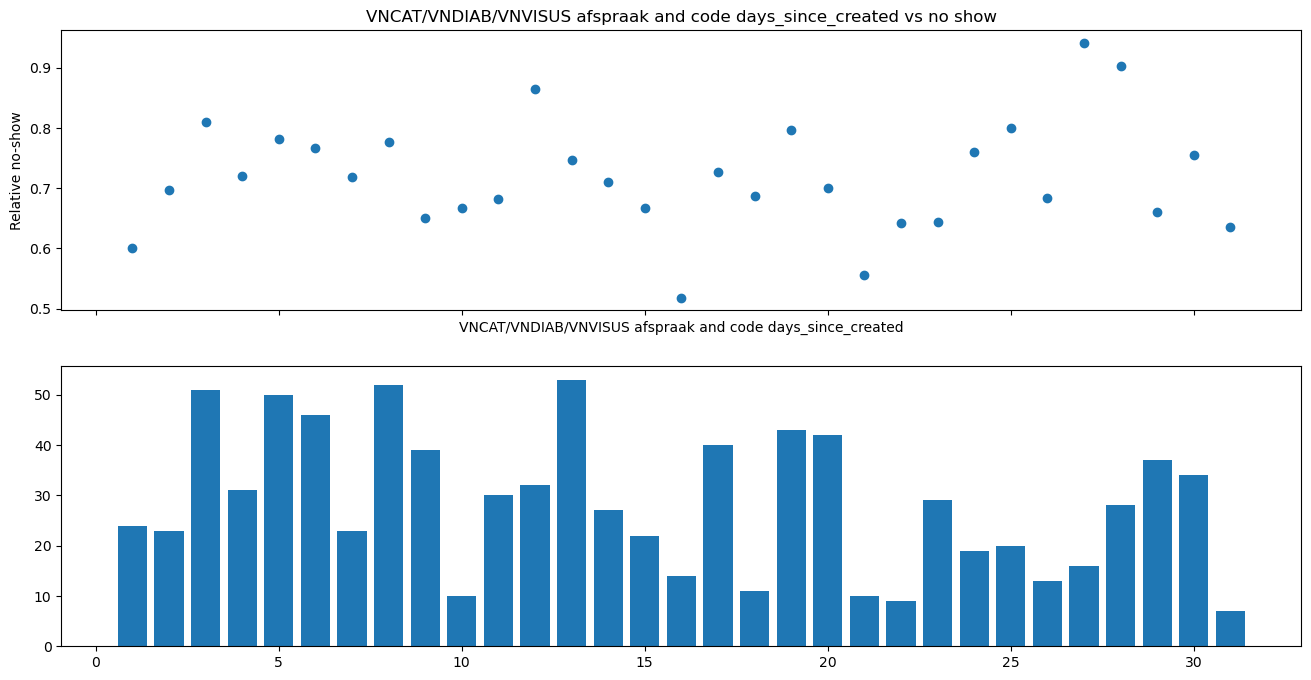

In [22]:
feature_scatter(new, "days_since_created", feature_name='VNCAT/VNDIAB/VNVISUS afspraak and code days_since_created')
plt.show()

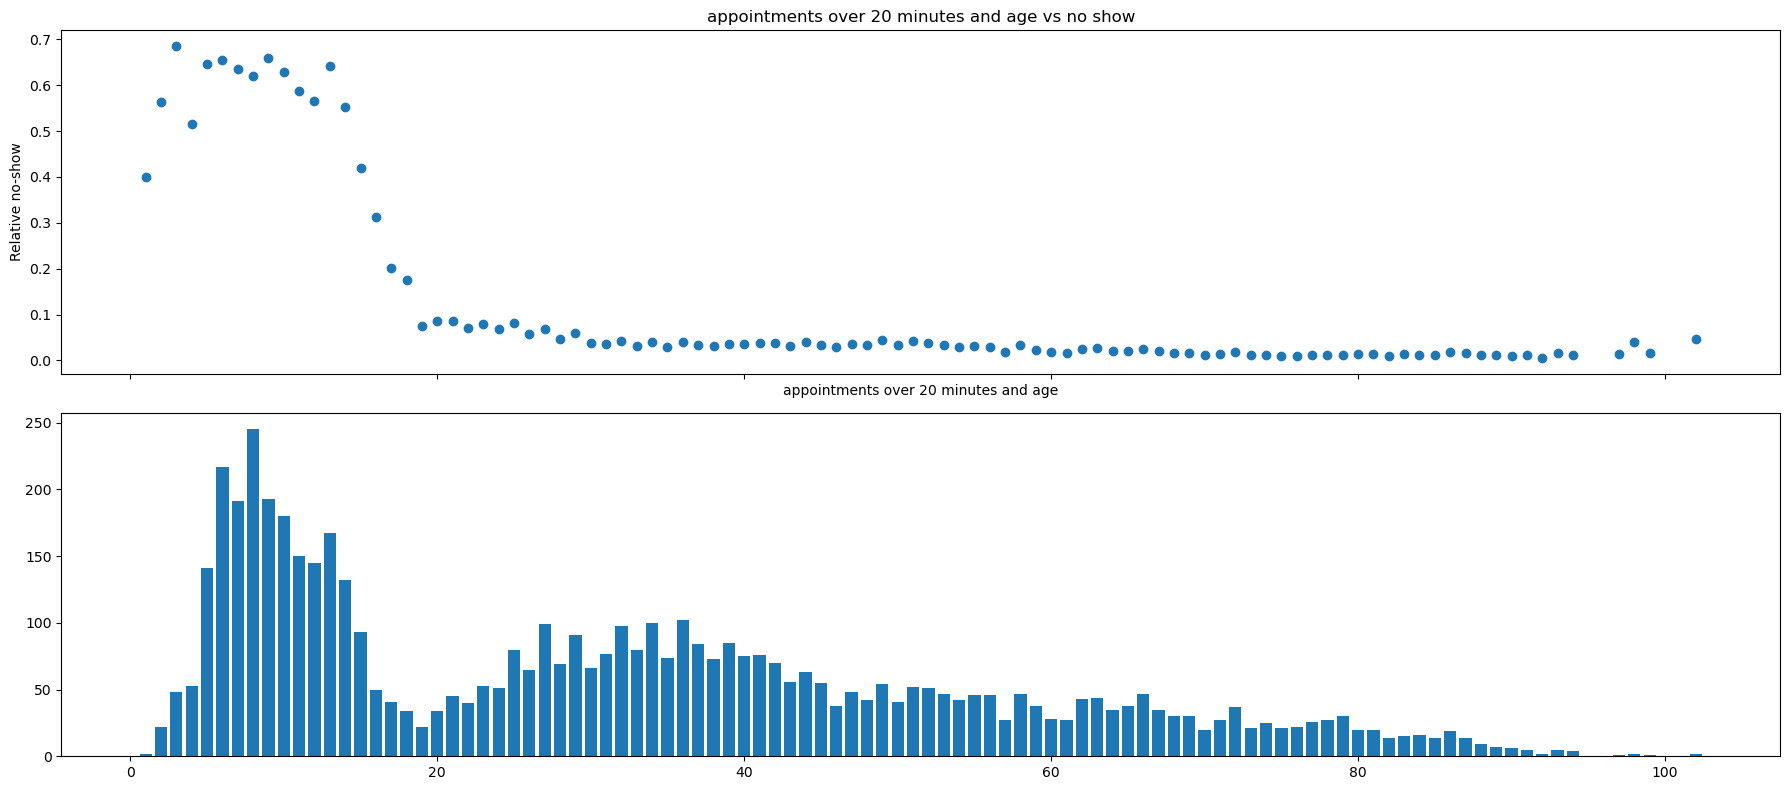

In [23]:
new = appointments_features[appointments_features['minutesDuration'] == 20]
ax = feature_scatter(new, "age", figsize=(18, 8), feature_name='appointments over 20 minutes and age')
plt.tight_layout()
plt.show()

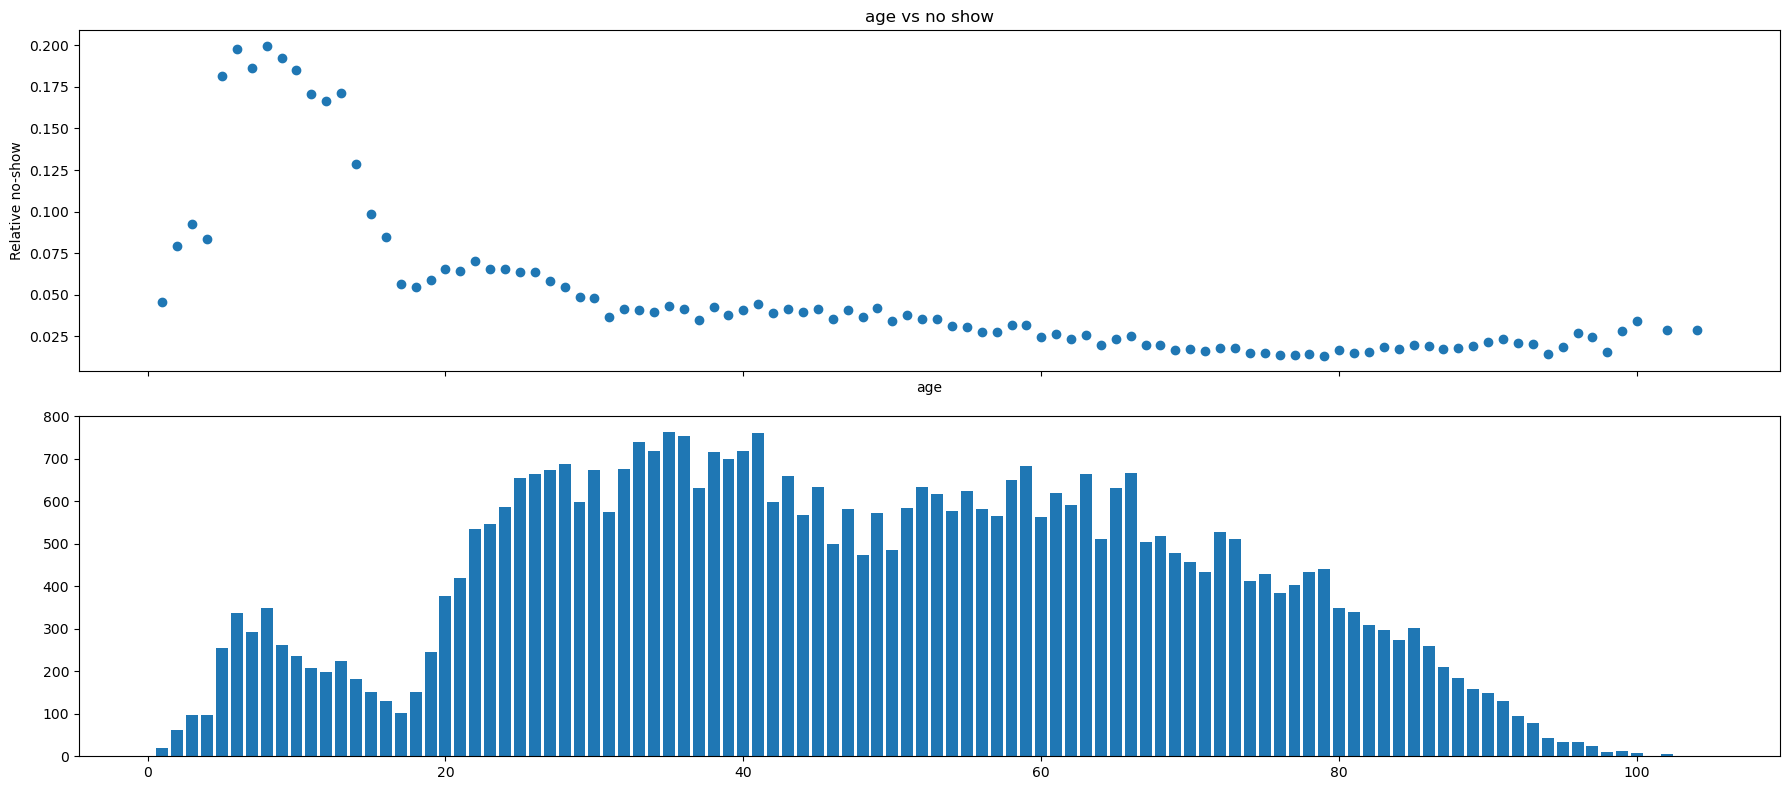

In [24]:
ax = feature_scatter(appointments_features, "age", figsize=(18, 8))
plt.tight_layout()
plt.show()

In [25]:
spearman = scipy.stats.spearmanr(appointments_features["dist_umcu"].tolist(), appointments_features["prev_no_show_perc"].tolist())
print(spearman)

SignificanceResult(statistic=-0.04352265454547873, pvalue=0.0)


In [26]:
"""
no_show_per_specialisation = (
    appointments_df.groupby("hoofdagenda")["no_show"].value_counts().unstack()
)

bottom = np.zeros(2)
fig, ax = plt.subplots(figsize=(10, 4))
for idx, row in no_show_per_specialisation.iterrows():
    ax.bar(["no-show", "show"], row, label=idx, bottom=bottom)
    bottom += row
ax.legend()

plt.show()
"""

'\nno_show_per_specialisation = (\n    appointments_df.groupby("hoofdagenda")["no_show"].value_counts().unstack()\n)\n\nbottom = np.zeros(2)\nfig, ax = plt.subplots(figsize=(10, 4))\nfor idx, row in no_show_per_specialisation.iterrows():\n    ax.bar(["no-show", "show"], row, label=idx, bottom=bottom)\n    bottom += row\nax.legend()\n\nplt.show()\n'

In [27]:
"""
no_show_percent = (
    appointments_df.groupby("no_show")["specialty_code"]
    .value_counts(normalize=True)
    .unstack(level="no_show")
)
fig, ax = plt.subplots(figsize=(10, 4))

bottom = np.zeros(2)
for idx, row in no_show_percent.iterrows():
    ax.bar(["no-show", "show"], row, label=idx, bottom=bottom)
    bottom += row

ax.legend()

plt.show()
"""

'\nno_show_percent = (\n    appointments_df.groupby("no_show")["specialty_code"]\n    .value_counts(normalize=True)\n    .unstack(level="no_show")\n)\nfig, ax = plt.subplots(figsize=(10, 4))\n\nbottom = np.zeros(2)\nfor idx, row in no_show_percent.iterrows():\n    ax.bar(["no-show", "show"], row, label=idx, bottom=bottom)\n    bottom += row\n\nax.legend()\n\nplt.show()\n'

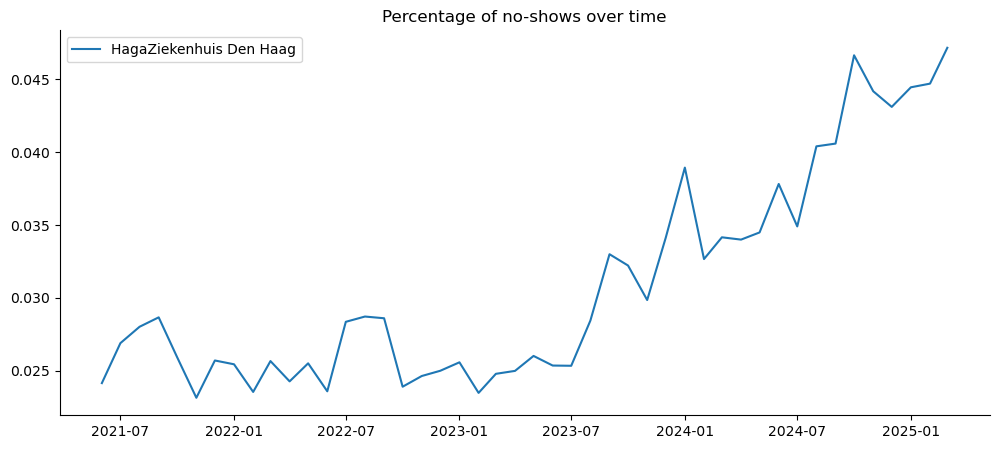

In [28]:
no_show_over_time = appointments_df.copy().reset_index()
no_show_over_time["start"] = (
    no_show_over_time["start"].dt.to_period("M").dt.to_timestamp()
)
no_show_over_time = (
    no_show_over_time.groupby(["ziekenhuis", "start"])["no_show"]
    .value_counts(normalize=True)
    .unstack(level="no_show")
)

fig, ax = plt.subplots(figsize=(12, 5))
for idx in no_show_over_time.index.unique(level="ziekenhuis"):
    ax.plot(
        no_show_over_time.loc[idx].index,
        no_show_over_time.loc[idx, "no_show"],
        label=idx,
    )
ax.legend()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.set_title("Percentage of no-shows over time")

plt.show()

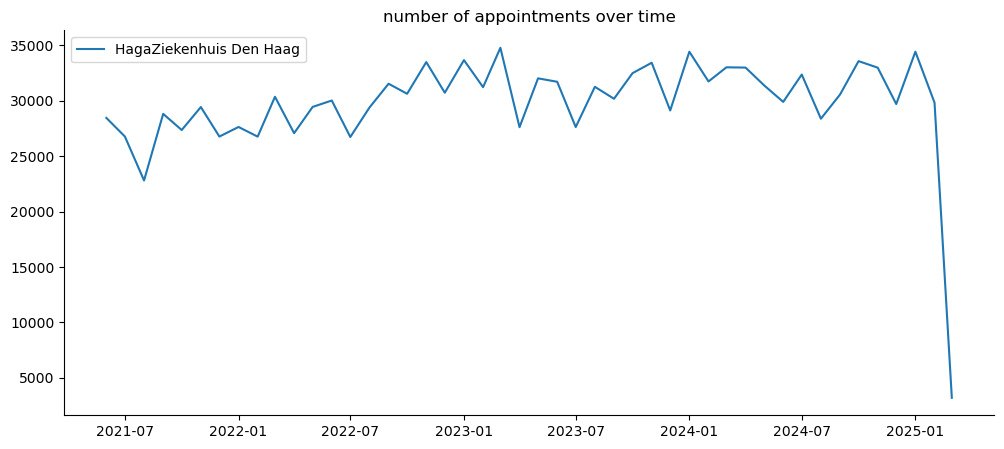

In [29]:
no_show_over_time = appointments_df.copy().reset_index()
no_show_over_time["start"] = (
    no_show_over_time["start"].dt.to_period("M").dt.to_timestamp()
)
no_show_over_time = no_show_over_time.groupby(["ziekenhuis", "start"])["no_show"].count()

fig, ax = plt.subplots(figsize=(12, 5))
for idx in no_show_over_time.index.unique(level="ziekenhuis"):
    ax.plot(
        no_show_over_time.loc[idx].index,
        no_show_over_time.loc[idx],
        label=idx,
    )
ax.legend()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.set_title("number of appointments over time")

plt.show()

In [30]:
print(no_show_over_time[0:10])

ziekenhuis               start     
HagaZiekenhuis Den Haag  2021-06-01    28461
                         2021-07-01    26782
                         2021-08-01    22815
                         2021-09-01    28825
                         2021-10-01    27368
                         2021-11-01    29441
                         2021-12-01    26778
                         2022-01-01    27643
                         2022-02-01    26771
                         2022-03-01    30368
Name: no_show, dtype: int64


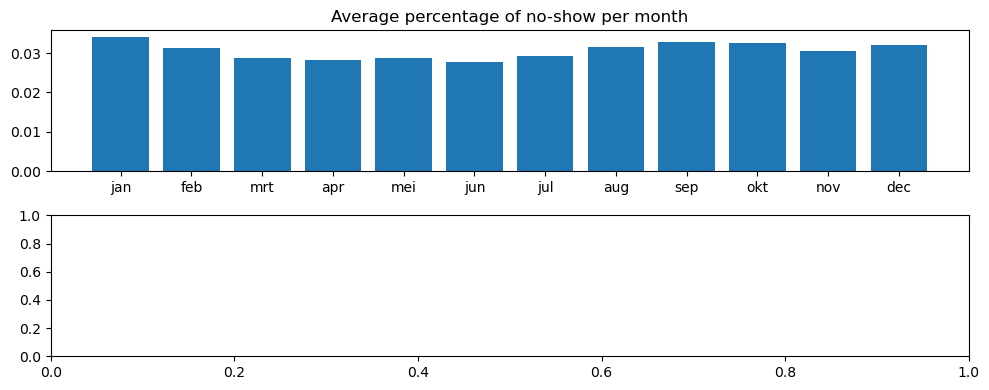

In [31]:
appointments_df["month"] = appointments_df.index.get_level_values("start").month
month_names = [
    "jan",
    "feb",
    "mrt",
    "apr",
    "mei",
    "jun",
    "jul",
    "aug",
    "sep",
    "okt",
    "nov",
    "dec",
]

no_show_month = (
    appointments_df.groupby(["month", "ziekenhuis"])["no_show"]
    .value_counts(normalize=True)
    .unstack(level="no_show")
)
fig, ax = plt.subplots(2, figsize=(10, 4))

for idx, clinic in zip(
    range(2), no_show_month.index.unique(level="ziekenhuis"), strict=False
):
    plot_data = no_show_month.loc[(slice(None), clinic), "no_show"]
    ax[idx].bar(month_names, plot_data, label=clinic)
    #ax[idx].legend()

ax[0].set_title("Average percentage of no-show per month")
fig.set_layout_engine("tight")
plt.show()

In [32]:
print(no_show_month)

no_show                         no_show      show
month ziekenhuis                                 
1     HagaZiekenhuis Den Haag  0.034073  0.965927
2     HagaZiekenhuis Den Haag  0.031222  0.968778
3     HagaZiekenhuis Den Haag  0.028801  0.971199
4     HagaZiekenhuis Den Haag  0.028149  0.971851
5     HagaZiekenhuis Den Haag  0.028712  0.971288
6     HagaZiekenhuis Den Haag  0.027722  0.972278
7     HagaZiekenhuis Den Haag  0.029137  0.970863
8     HagaZiekenhuis Den Haag  0.031457  0.968543
9     HagaZiekenhuis Den Haag  0.032733  0.967267
10    HagaZiekenhuis Den Haag  0.032677  0.967323
11    HagaZiekenhuis Den Haag  0.030624  0.969376
12    HagaZiekenhuis Den Haag  0.032064  0.967936


## Calculate earlier no-shows

In [33]:
appointments_features = prev_no_show_features(appointments_df)

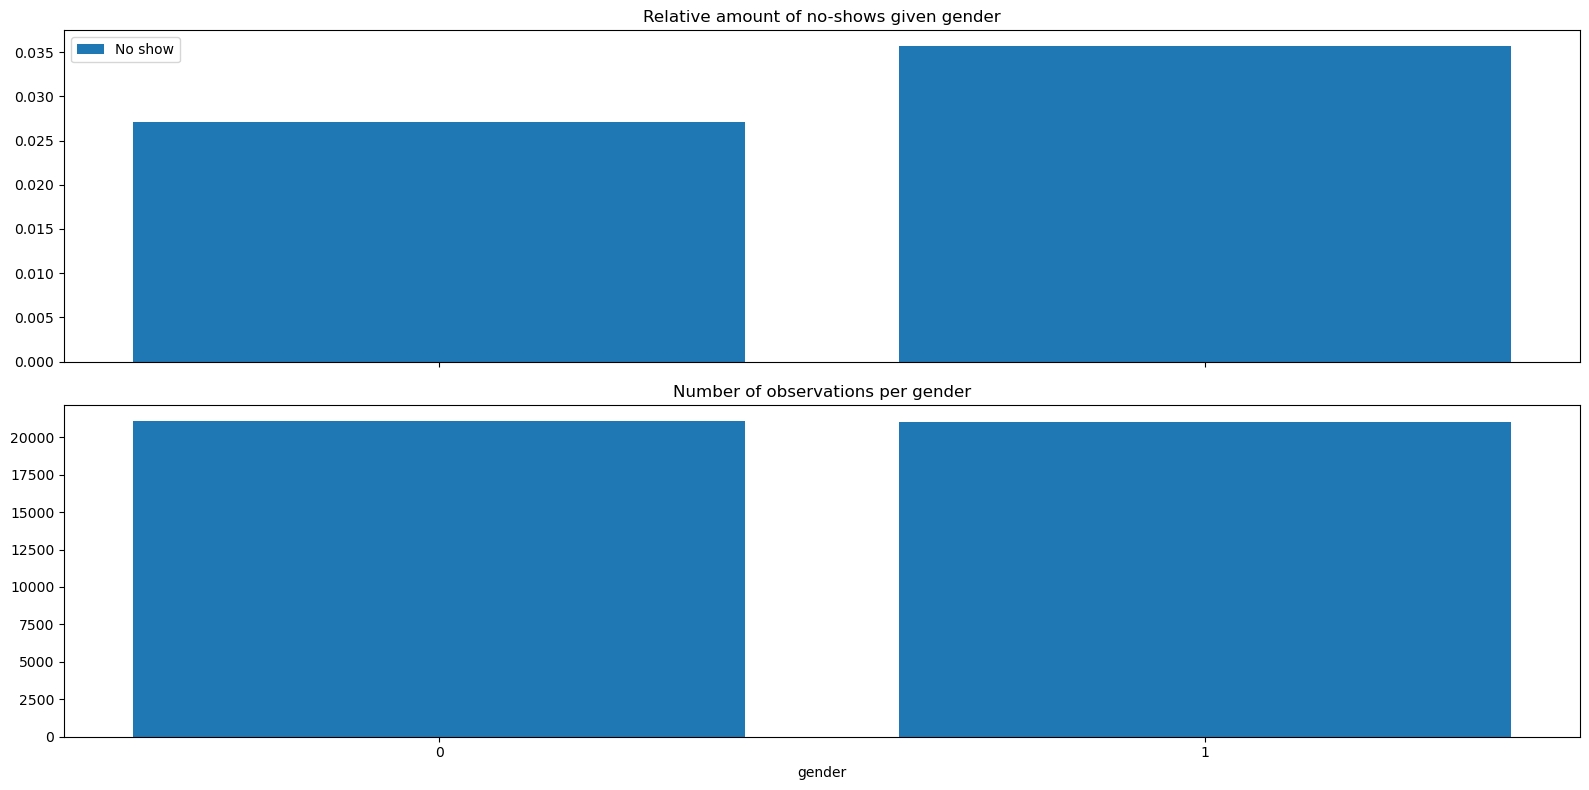

In [34]:
ax = feature_barplot(
    appointments_features,
    "gender",
    feature_name="gender",
)
plt.tight_layout()
plt.show()

In [35]:
test = (appointments_features['earlier_appointments'] == 0).sum()
print(test)

227251


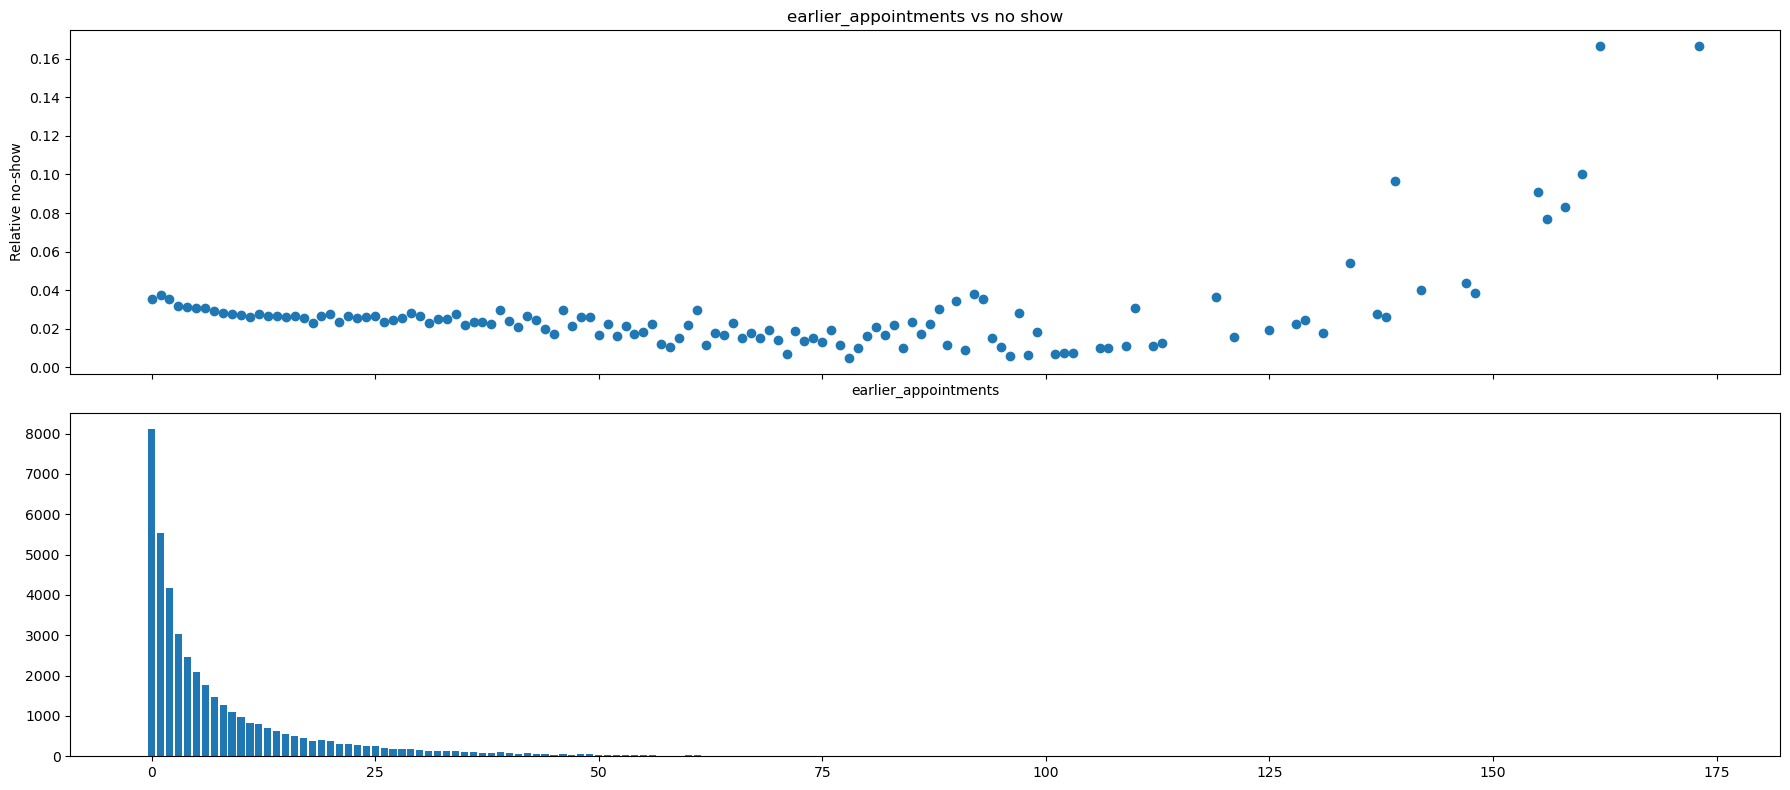

In [36]:
ax = feature_scatter(appointments_features, "earlier_appointments", figsize=(18, 8))
plt.tight_layout()
plt.show()

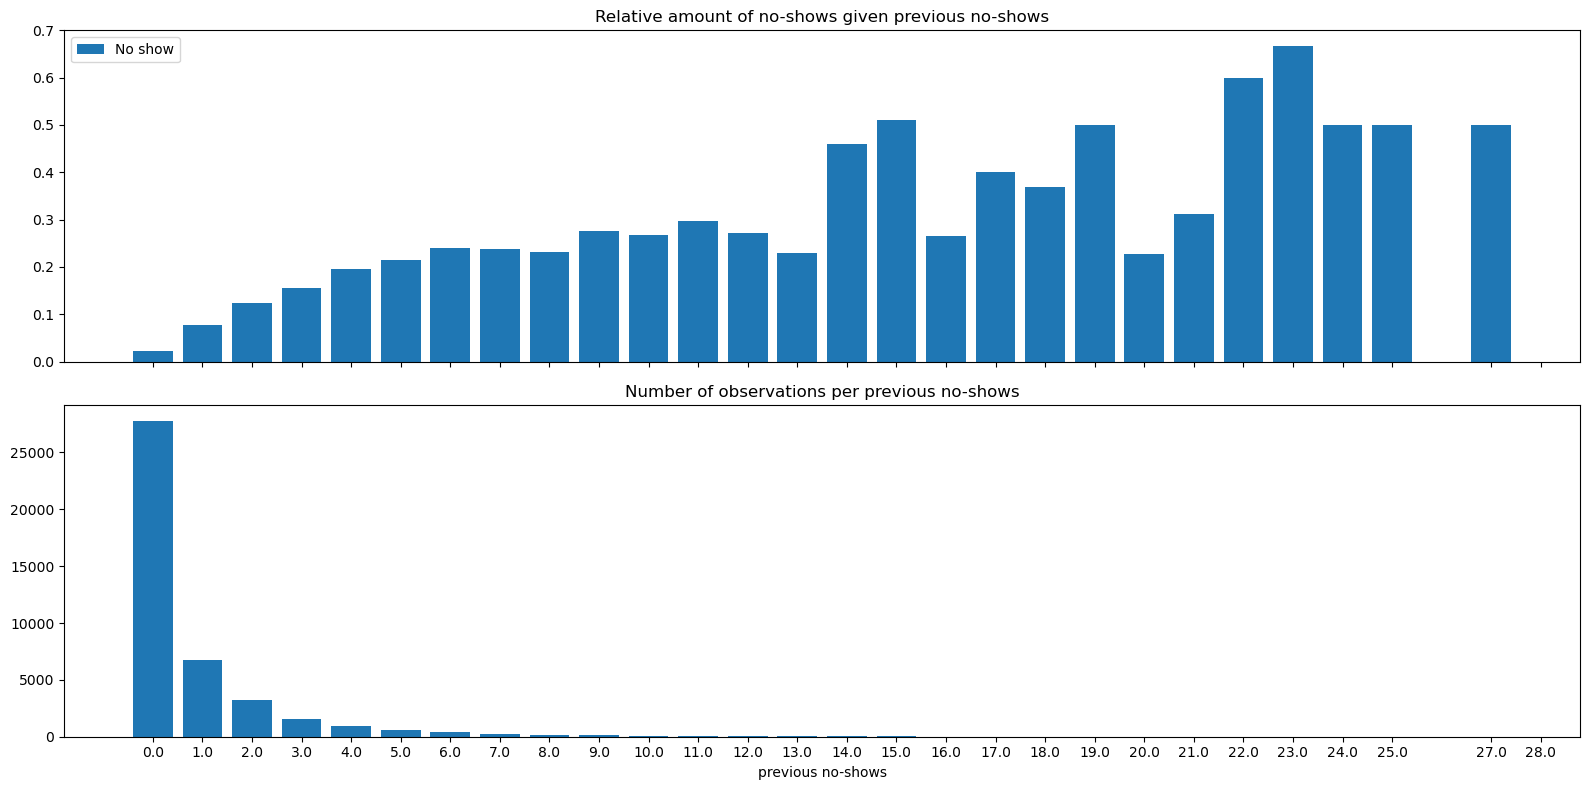

In [37]:
ax = feature_barplot(
    appointments_features,
    "prev_no_show",
    feature_name="previous no-shows",
)
plt.tight_layout()
plt.show()

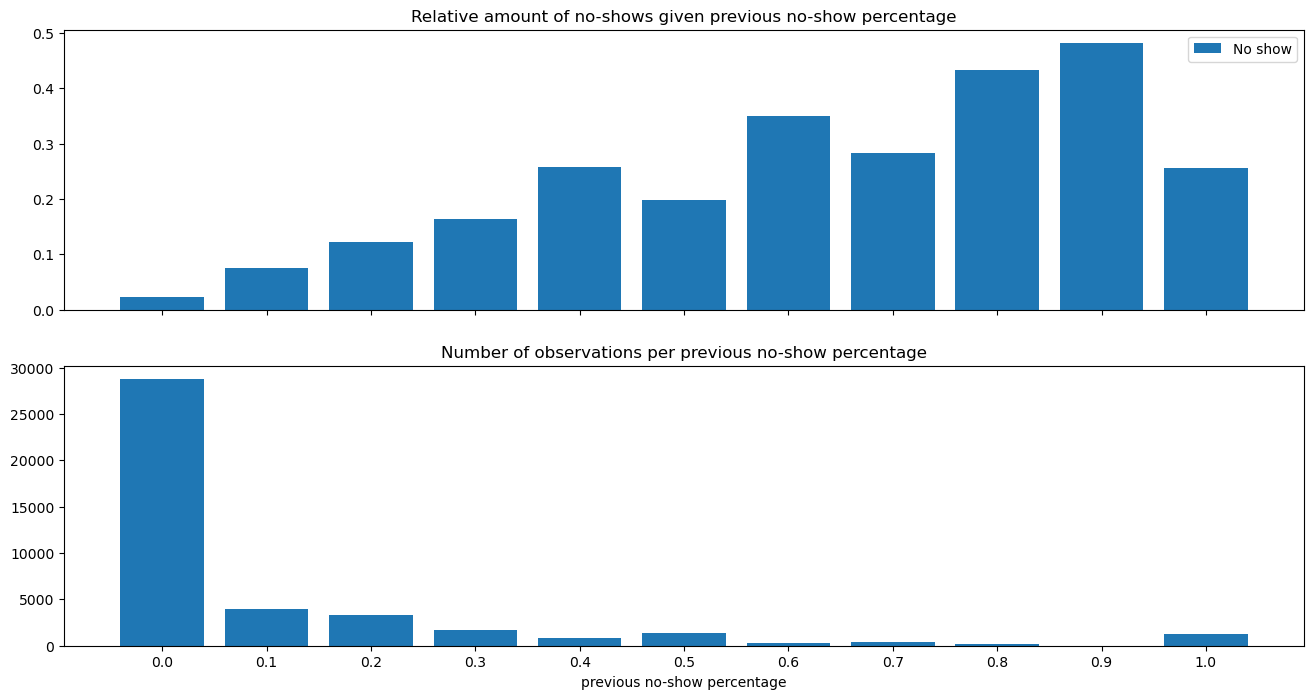

In [38]:
feature_barplot(
    appointments_features,
    "prev_no_show_perc",
    feature_name="previous no-show percentage",
    perc_feature=True,
    round_decimals=1,
)
plt.show()

### Calculate days since created

In [39]:
appointments_features = add_days_since_created(appointments_features)

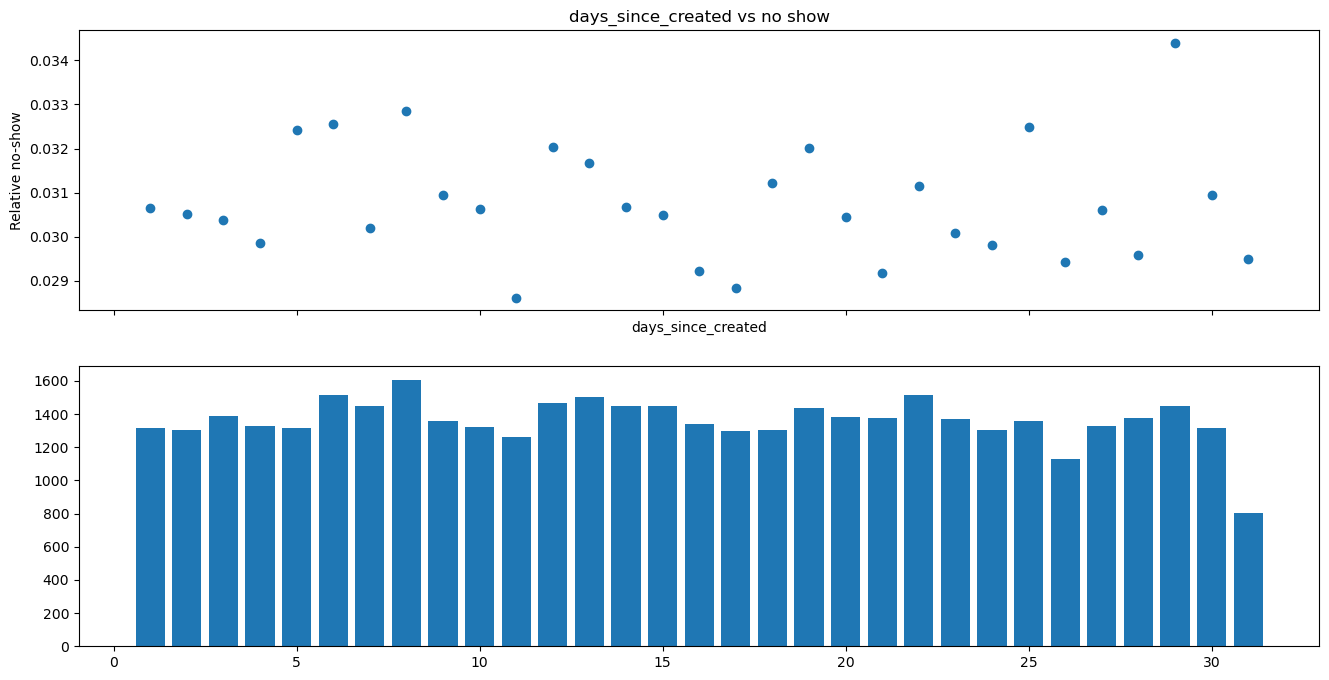

In [40]:
feature_scatter(appointments_features, "days_since_created")
plt.show()

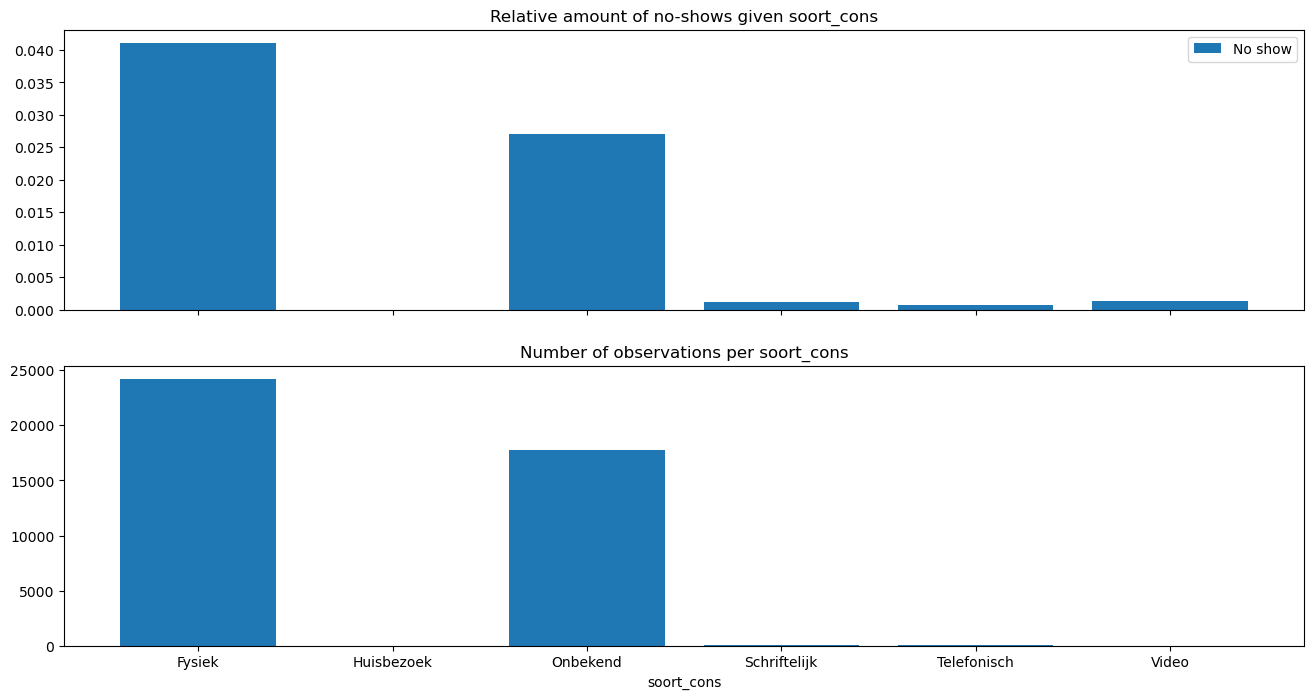

In [41]:
feature_barplot(appointments_features, "soort_cons")
plt.show()

### Calculate appointments on the same day

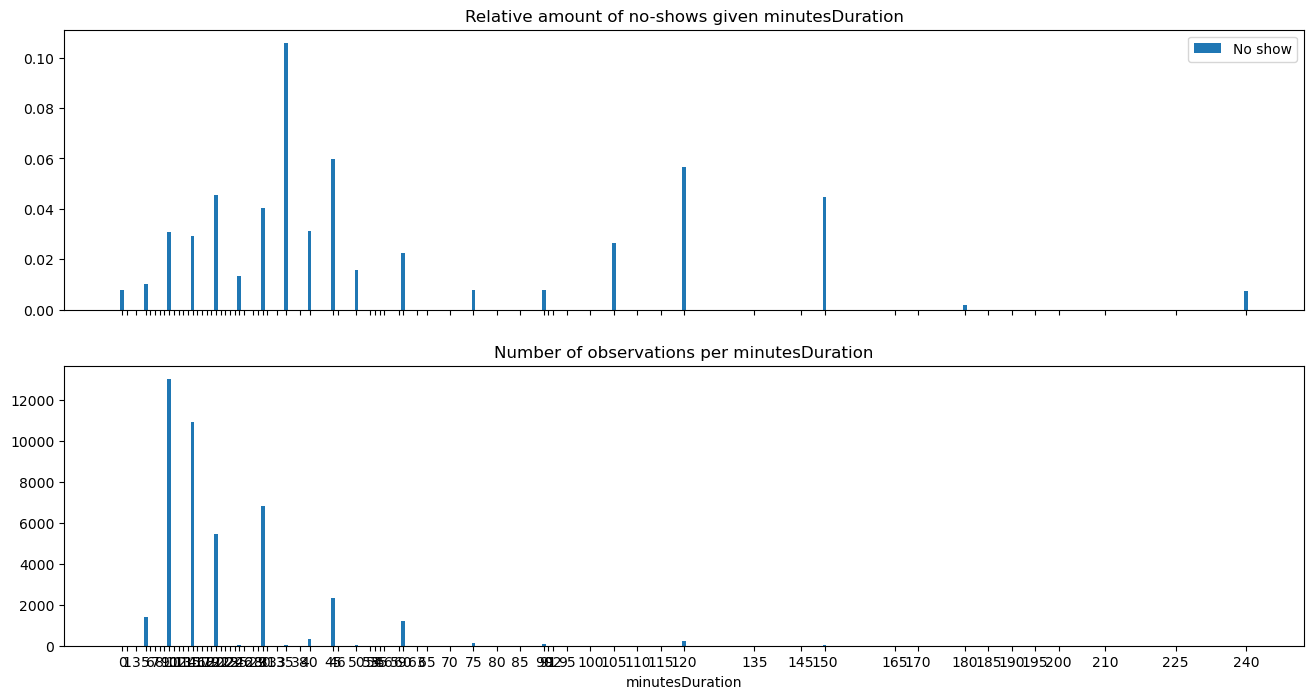

In [42]:
feature_barplot(appointments_features, "minutesDuration")
plt.show()

In [43]:
appointments_features = add_appointments_same_day(appointments_features)

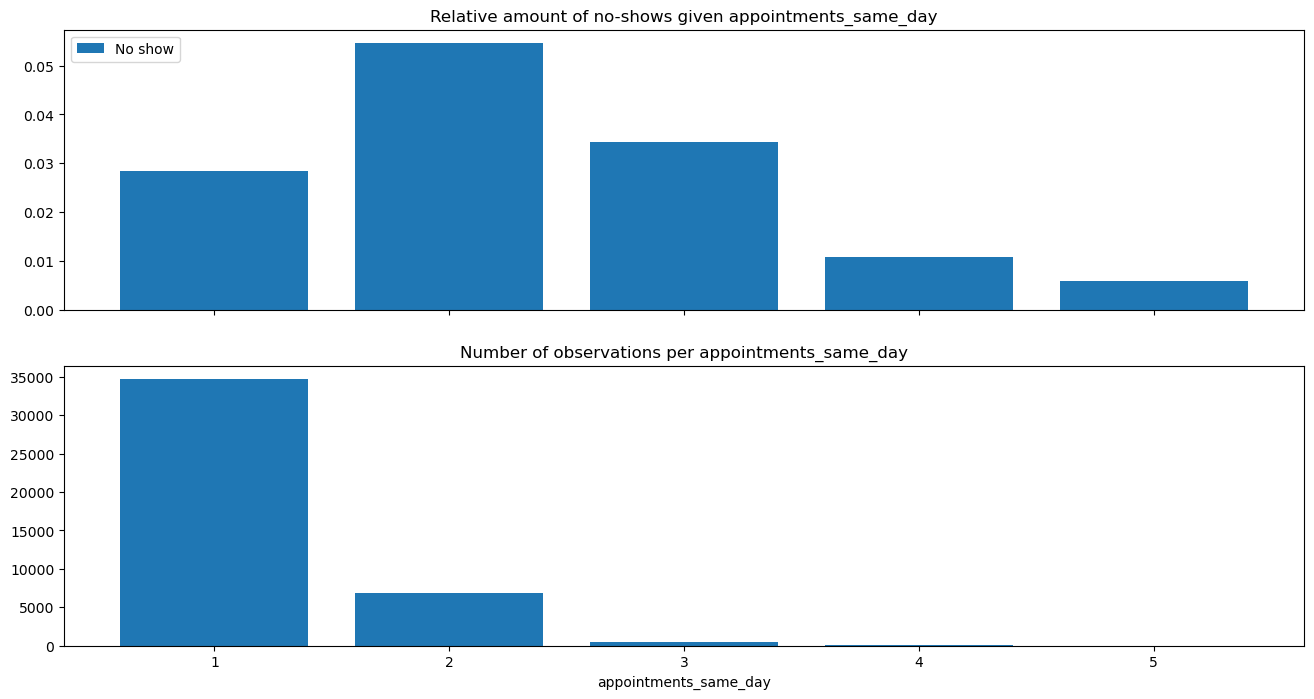

In [44]:
feature_barplot(appointments_features, "appointments_same_day")
plt.show()

In [45]:
appointments_features = add_days_since_last_appointment(appointments_features)
appointments_features = add_appointments_last_days(appointments_features)

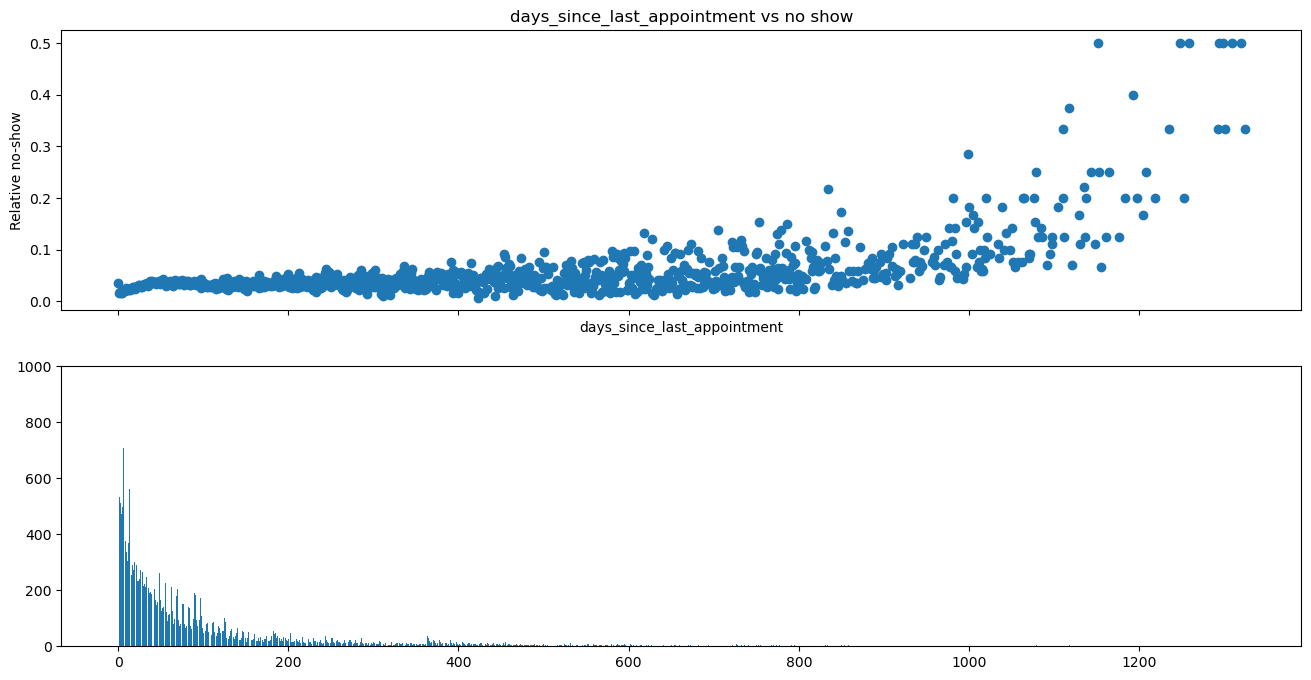

In [46]:
ax = feature_scatter(appointments_features, "days_since_last_appointment")
ax[1].set_ylim(0, 1000)
plt.show()

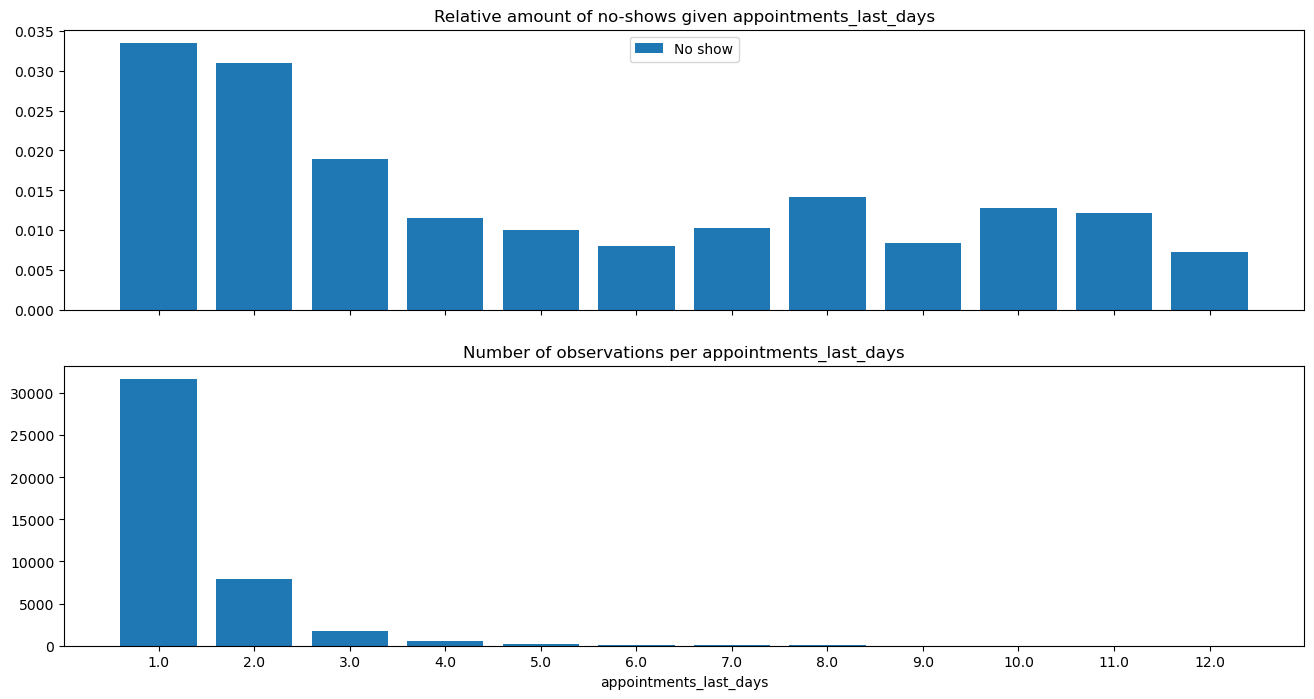

In [47]:
feature_barplot(appointments_features, "appointments_last_days")
plt.show()

## Calculate patient features

### Postal codes

Using the dump from https://download.geonames.org/export/zip/

In [48]:
all_postalcodes = process_postal_codes("../data/raw/NL.csv")
appointments_features = add_patient_features(appointments_features, all_postalcodes)

---


### Plot patient features

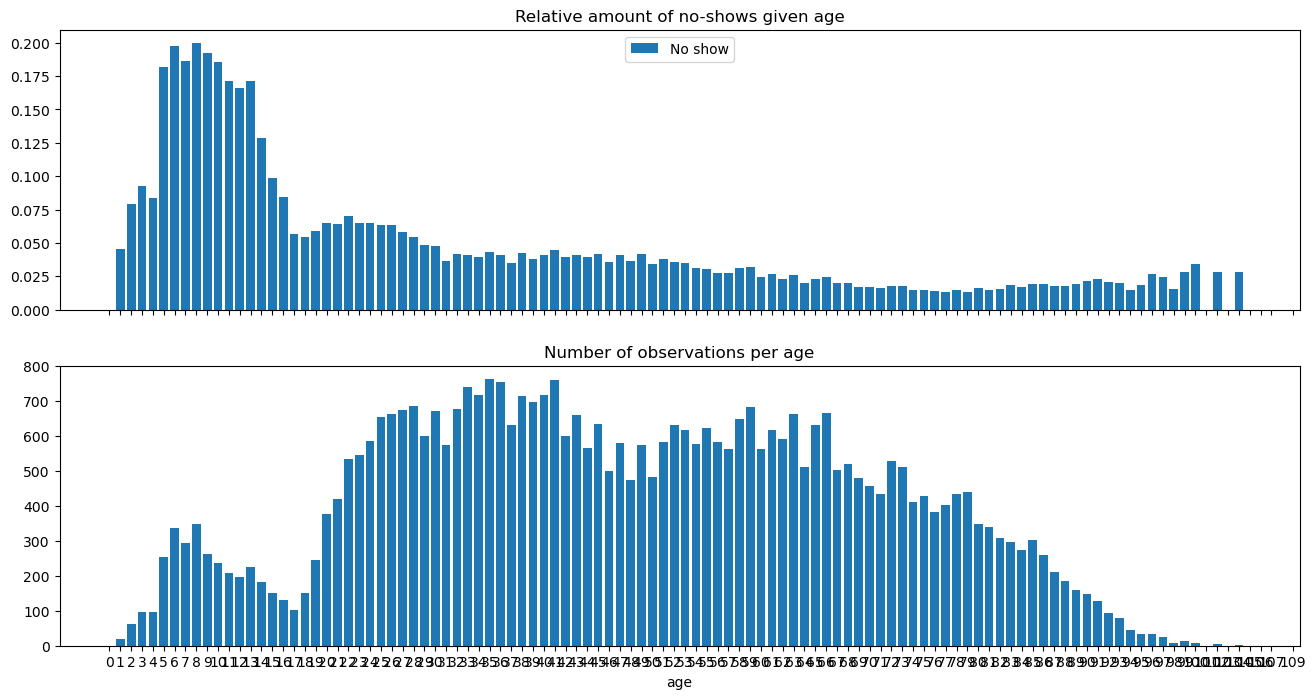

In [49]:
feature_barplot(appointments_features, "age")
plt.show()

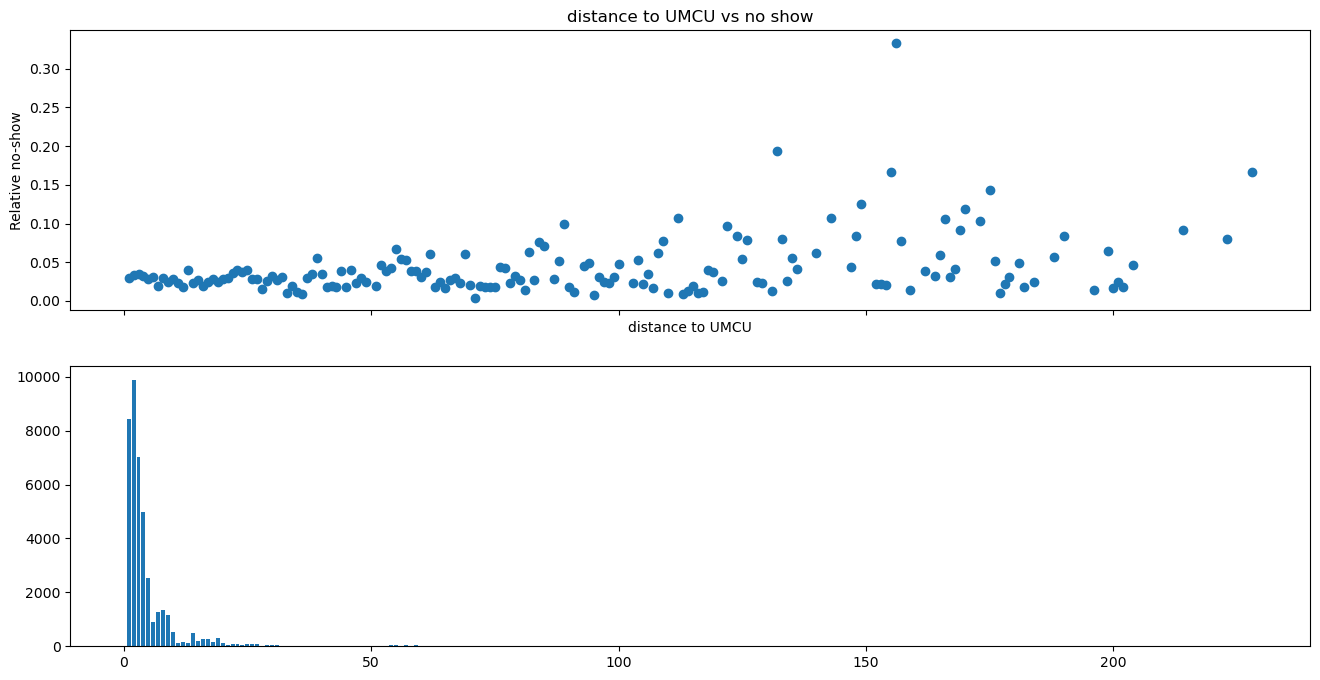

In [50]:
feature_scatter(
    appointments_features,
    "dist_umcu",
    feature_name="distance to UMCU",
    round_feature=True,
)
plt.show()

## Calculate punctuality patients

In [51]:
appointments_features = add_minutes_early(appointments_features)

<Axes: ylabel='Frequency'>

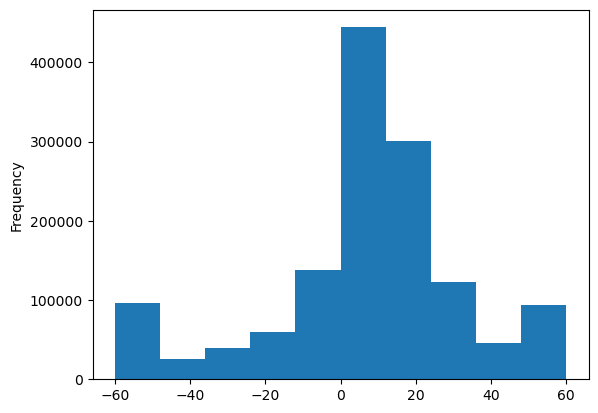

In [52]:
appointments_features["minutes_early"].plot.hist(bins=10)

### Plot punctuality vs no show

In [53]:
appointments_features["prev_minutes_early_na"] = appointments_features[
    "prev_minutes_early"
].isna()
appointments_features.groupby("no_show")["prev_minutes_early_na"].value_counts(
    normalize=True
).unstack()

prev_minutes_early_na,False
no_show,
no_show,1.0
show,1.0


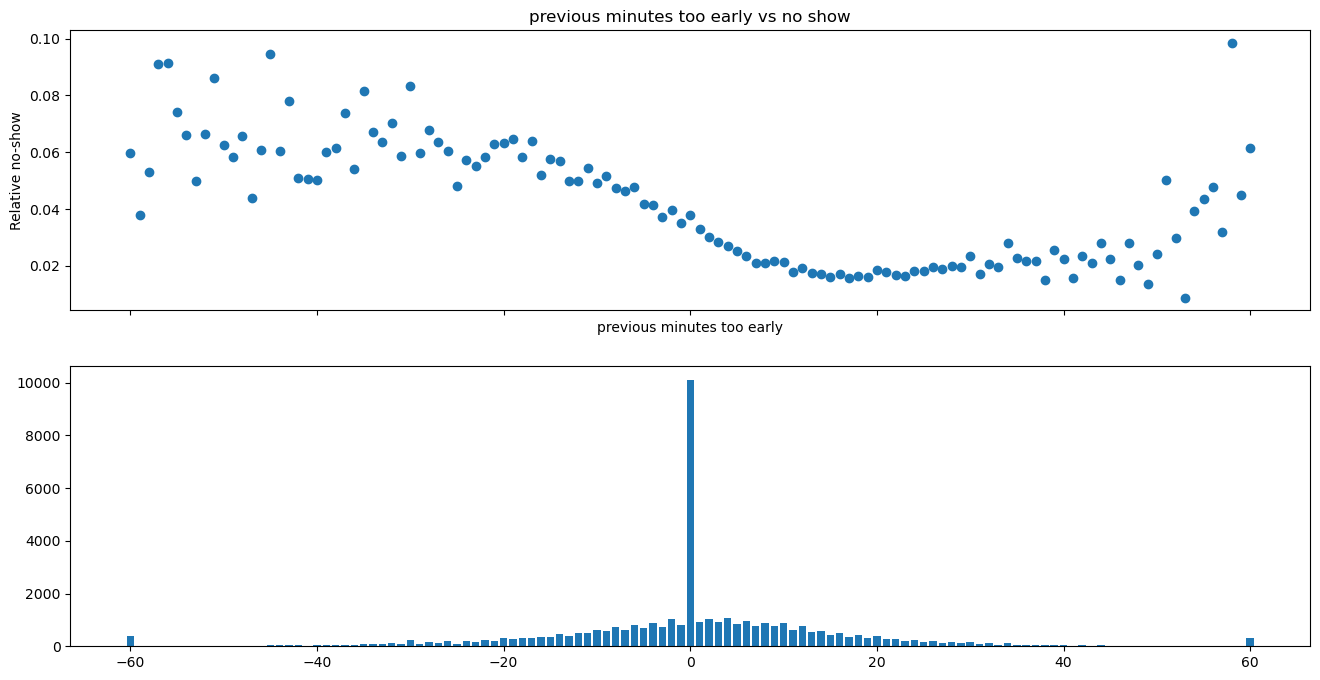

In [54]:
feature_scatter(
    appointments_features,
    "prev_minutes_early",
    feature_name="previous minutes too early",
    round_feature=True,
)
plt.show()

## Add time features

In [55]:
appointments_features = add_time_features(appointments_features)

In [56]:
test = (appointments_features[appointments_features['hour'] == 18])
test = test[test['no_show'] == 'no_show']
print(test['soort_consult'].value_counts())

soort_consult
Administratie                         113
Onbekend                               59
controle patient gyn 15 minuten        16
Nieuwe patiënt spoed                   11
Kolposcopie                             8
Controle patiënt                        4
Nieuwe patiënt - fertiliteit Vrouw      3
Echo gyn aangevraagd door huisarts      2
Nieuwe patiënt Obstetrie                2
IUD plaatsen                            2
echo verloskundige                      2
Nieuwe patiënt - fertiliteit Man        2
Gluco nieuwe patient patient            2
nieuwe patient gyn 20 minuten           2
Echo verloskundige                      2
overige GYN                             1
Controle patiënt Obstetrie              1
Onco patiënt                            1
Nieuwe patiënt                          1
BBC controle patiënt                    1
Controle patiënt fertiliteit Vrouw      1
Spiro/CO                                1
ZOL/EUG                                 1
BBC nieuwe patient  

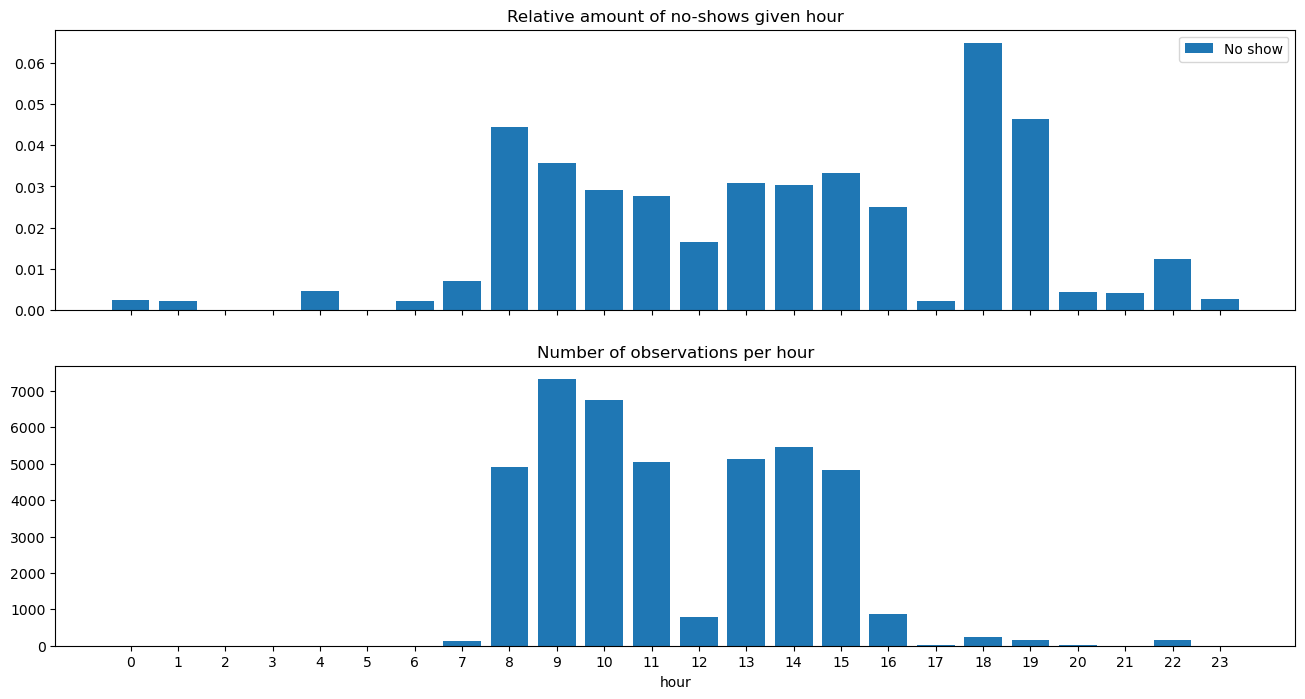

In [57]:
feature_barplot(appointments_features, "hour")
plt.show()

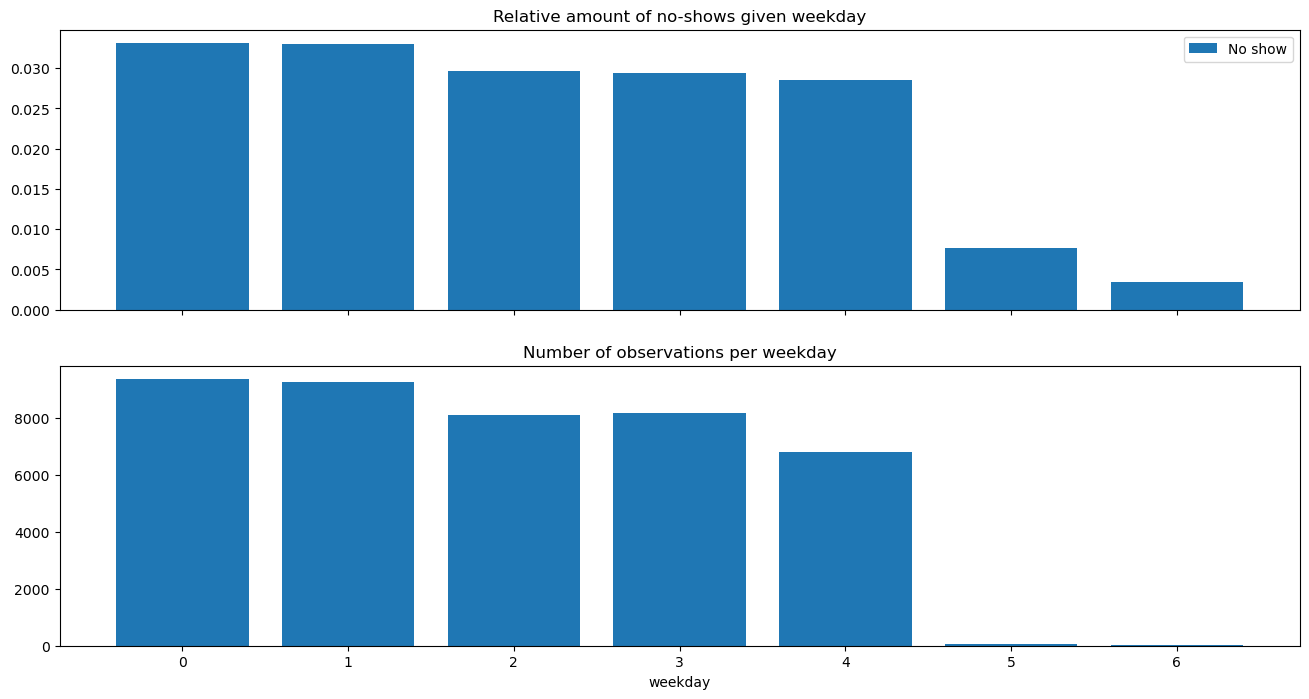

In [58]:
feature_barplot(appointments_features, "weekday")
plt.show()

## Plot categorical features

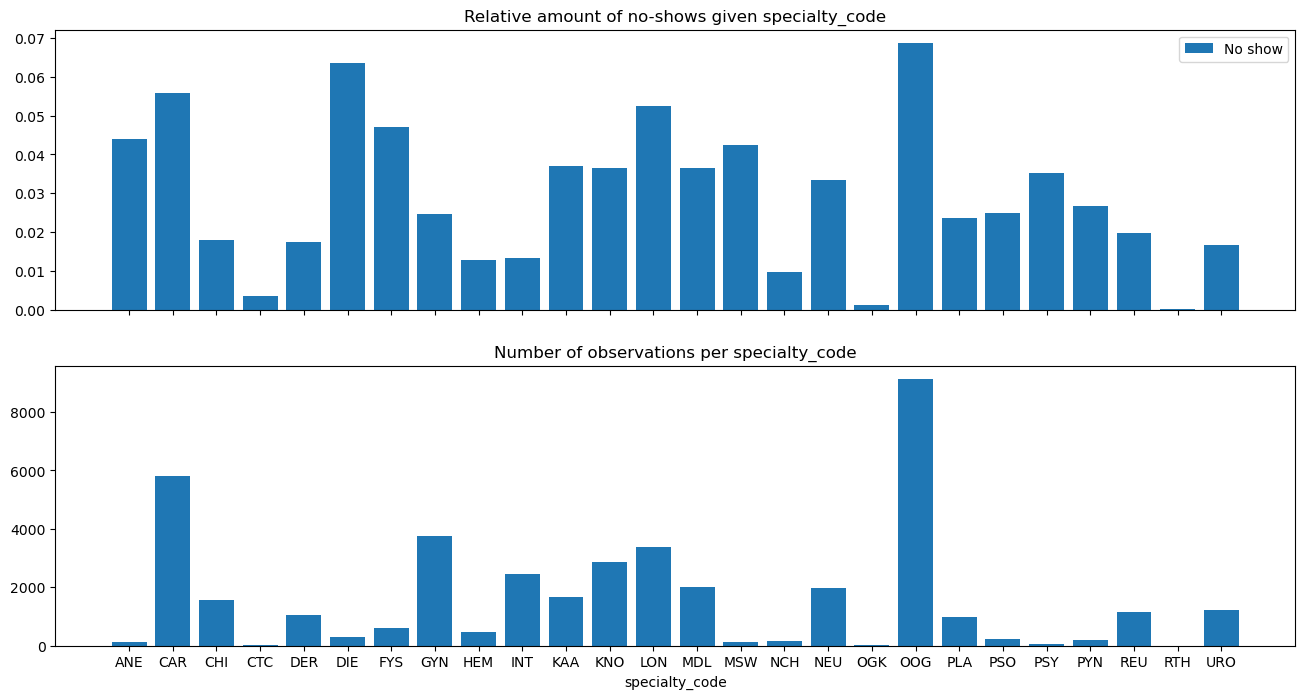

In [59]:
ax = feature_barplot(appointments_features, "specialty_code")
plt.show()

In [60]:
#count = appointments_features[appointments_features['earlier_appointments'] > 280]
#print(count)

In [61]:
test = appointments_df['APP_ID'].value_counts()
print(test)

APP_ID
22865425    1
18975181    1
20425591    1
20579611    1
23252011    1
           ..
19149155    1
20788565    1
21876295    1
23406879    1
24868208    1
Name: count, Length: 1368259, dtype: int64
